In [1]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [2]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [3]:
modeApi = lumapi.MODE(hide = False)

#units

um = 1e-6
nm = 1e-9

## Specifying the device and solver dimensions, materials and properties ##

In [4]:
#Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

#Device dimensions:

width = np.linspace(0.45,1.75,21)*um
height = 0.22 * um

#Solver dimensions:

width_solver = 4*width
height_solver = 4*height

#mesh dimensions:

mesh_width = width
mesh_height = height

#Solver and properties:

solver_mesh_cells = 200
mesh_multiplier = 3

## Building the device ##

In [5]:
modeApi.addrect()
modeApi.set('name', 'rec')
modeApi.set('x', 0)
modeApi.set('x span', width[-1])
modeApi.set('y', 0)
modeApi.set('y span', height)
modeApi.set('material', material)

#Add solver:
modeApi.addfde()
modeApi.set('x', 0)
modeApi.set('x span', width_solver[-1])
modeApi.set('y', 0)
modeApi.set('y span', height_solver)
modeApi.set('background material', sub_material)
modeApi.set('mesh cells x', solver_mesh_cells)
modeApi.set('mesh cells y', solver_mesh_cells)
modeApi.set('x min bc', 'PML')
modeApi.set('x max bc', 'PML')
modeApi.set('y min bc', 'PML')
modeApi.set('y max bc', 'PML')

#Add mesh

modeApi.addmesh()
modeApi.set('x', 0)
modeApi.set('x span', mesh_width[-1])
modeApi.set('y', 0)
modeApi.set('y span', mesh_height)
modeApi.set('set mesh multiplier', 1)
modeApi.set('x mesh multiplier', mesh_multiplier)
modeApi.set('y mesh multiplier', mesh_multiplier)

modeApi.save('RIDGE_waveguide_FDE')

In [6]:
modeApi.findmodes()

8.0

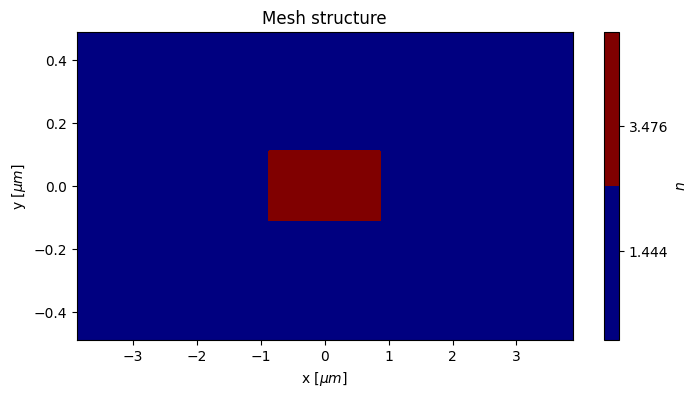

In [7]:
index_x = np.squeeze(modeApi.getdata('FDE::data::material', 'index_x'))
x_structure = np.squeeze(modeApi.getdata('FDE::data::material', 'x'))/um
y_structure = np.squeeze(modeApi.getdata('FDE::data::material', 'y'))/um

X, Y = np.meshgrid(x_structure, y_structure)
v = np.linspace(np.min(index_x), np.max(index_x), 2)

im = plt.contourf(X, Y, np.rot90(index_x), 0, cmap = plt.get_cmap('jet'), vmin = v[0], vmax = v[-1], origin = 'lower')
colorbar = plt.colorbar(im, label = r'$n$')
colorbar.set_ticks(v)
plt.xlabel(r'x [$\mu m$]')
plt.ylabel(r'y [$\mu m$]')
plt.title('Mesh structure')
#plt.xlim([-0.5,0.5])
#plt.ylim([-0.45/2,0.45/2])
plt.show()

## Raising the graph $n_{eff}$ x $w$ ##

In [8]:
Nmax = int(modeApi.findmodes())

n_eff_matrix = np.zeros((len(width),Nmax))
TE_polarization_matrix = np.zeros((len(width),Nmax))

In [9]:
for i in range(0, len(width), 1):
    modeApi.switchtolayout()
    modeApi.setnamed('rec', 'x span', width[i])
    modeApi.setnamed('FDE', 'x span', width_solver[i])
    modeApi.setnamed('mesh', 'x span', mesh_width[i])
    n = int(modeApi.findmodes())
    for j in range(0, n, 1):
        n_eff_matrix[i,j] = np.real(modeApi.getdata('mode%d' %(j+1), 'neff'))[0,0]
        TE_polarization_matrix[i,j] = modeApi.getdata('mode%d' %(j+1), 'TE polarization fraction')

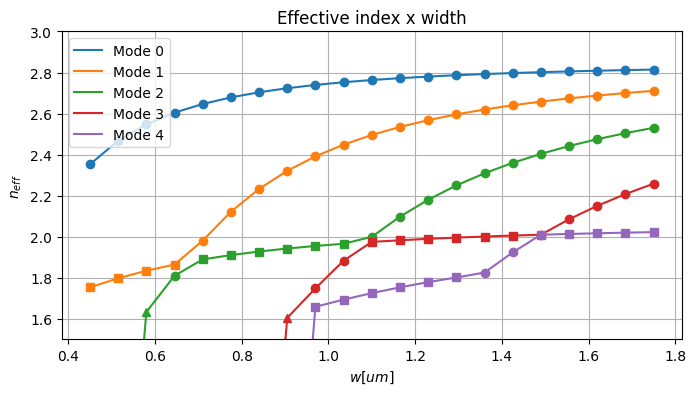

Markers:
●: TE mode
■: TM mode
▲: Hybrid mode


In [27]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig = plt.figure(figsize=(8, 4))

n_modes = 5

for j in range(0, n_modes, 1):
    plt.plot(width/um, n_eff_matrix[:,j], '-', label = 'Mode %d' %(j))

for j in range(0, n_modes, 1):
    for i in range(0, len(width), 1):
        if TE_polarization_matrix[i,j] > 0.85:
            plt.plot(width[i]/um, n_eff_matrix[i,j], 'o', color = colors[j])
        elif TE_polarization_matrix[i,j] < 0.15:
            plt.plot(width[i]/um, n_eff_matrix[i,j], 's', color = colors[j])
        else:
            plt.plot(width[i]/um, n_eff_matrix[i,j], '^', color = colors[j])

plt.ylim([1.5, 3])
plt.xlabel(r'$w [um]$')
plt.ylabel(r'$n_{eff}$')
plt.grid(True)
plt.title('Effective index x width')
plt.legend(loc = 'best')
plt.show()

print('\033[1mMarkers:\n\u25CF: TE mode\n\u25A0: TM mode\n\u25B2: Hybrid mode\033[0m')

In [28]:
modeApi.close()